In [1]:
# set backend for bayesflow
import os
os.environ["KERAS_BACKEND"] = "jax"

# import posterior approximator (standard NPE and DRO-NPE)
import bayesflow as bf
import keras
import numpy as np
from bayesflow.approximators.continuous_approximator import ContinuousApproximator
from src.approximator.continuous_approximator_dro_ub import ContinuousApproximatorDROUB

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/hikiday1/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
INFO:bayesflow:Using backend 'jax'
/Users/hikiday1/Project/dro-sbi/dro_sbi/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Preperation

We demonstrate our DRO-NPE with Lotka–Volterra simulator. We set simulation budget $n = 1024$

In [2]:
# set seed
seed = 2025
keras.utils.set_random_seed(seed)
np.random.seed(seed)
rng = np.random.default_rng(seed)

# Simulate data
from bayesflow.simulators import LotkaVolterra
n = 1024
simulator = LotkaVolterra(rng = rng)
training_data = simulator.sample(batch_shape=(n,)) 

In [3]:
print("x shape:", training_data["observables"].shape)
print("theta shape:", training_data["parameters"].shape)

x shape: (1024, 20)
theta shape: (1024, 4)


In [4]:
# set up adapter to convert data to correct format for bayesflow
adapter = (
    bf.adapters.Adapter()
    .to_array()
    .convert_dtype("float64", "float32")
    .rename("parameters", "inference_variables")
    .rename("observables", "inference_conditions")
)

## Training

Although in practice we need to tune `epsilon`, here we just set `epsilon = 0.11`, a value tuned beforehand.

In [5]:
# set inference network
from bayesflow.networks.coupling_flow import CouplingFlow
inference_network = CouplingFlow(subnet_kwargs = {"activation": "tanh"}) # use tanh activation to satisfy the boundedness needed for our theory.

# set up dataloader 
from bayesflow.datasets import OfflineDataset
batch_size = 64
dataset = OfflineDataset(training_data, batch_size = batch_size, adapter = adapter)

# set DRO-NPE approximator
epsilon = 0.11
approximator_dro = ContinuousApproximatorDROUB(
    inference_network = inference_network,
    adapter = adapter,
    epsilon = epsilon,
)

In [6]:
# train DRO-NPE approximator
optimizer = keras.optimizers.AdamW(learning_rate=5e-4, clipnorm=1.1)
approximator_dro.compile(optimizer=optimizer)
history = approximator_dro.fit(dataset = dataset, epochs = 1000, batch_size = 64)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 4.5802 - loss/inference_loss: 4.4300 - regularization/inference_regularization: 0.1501
Epoch 2/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.0484 - loss/inference_loss: 3.7872 - regularization/inference_regularization: 0.2612
Epoch 3/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.2111 - loss/inference_loss: 2.8957 - regularization/inference_regularization: 0.3154
Epoch 4/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.9819 - loss/inference_loss: 2.5126 - regularization/inference_regularization: 0.4693
Epoch 5/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.9239 - loss/inference_loss: 1.3690 - regularization/inference_regularization: 0.5549
Epoch 6/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.0301 - loss/inference_loss: 1.2911 - regularization/inference_regularization: 0.7390
Epoch 7/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.0765 - loss/inference_loss: 1.2168 - regularization/infe

For comparison, we also train NPE approximator.

In [7]:
# train standard NPE
inference_network_npe = CouplingFlow(subnet_kwargs = {"activation": "tanh"})
approximator_npe = ContinuousApproximator(
    inference_network = inference_network_npe,
    adapter = adapter,
)
approximator_npe.compile(optimizer=optimizer)
history_npe = approximator_npe.fit(dataset = dataset, epochs = 1000, batch_size = 64)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.2307
Epoch 2/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.3932
Epoch 3/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.7855
Epoch 4/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.2695
Epoch 5/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.7629
Epoch 6/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.2775
Epoch 7/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8555
Epoch 8/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.5374
Epoch 9/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.2919
Epoch 10/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0628
Epoch 11/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9163
Epoch 12/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7405
Epoch 13/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6227
Epoch 14/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4210
Epoch 15/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - lo

## Evaluation

Here we evaluate our DRO-NPE and NPE.

In [8]:
test_data = simulator.sample(batch_shape = (100,))

In [9]:
# sample from approximated posteriors
post_samples_dro = approximator_dro.sample(conditions = test_data, num_samples = 5000)["parameters"]
post_samples_npe = approximator_npe.sample(conditions = test_data, num_samples = 5000)["parameters"]

Sampling: 100%|██████████| 1/1 [00:00<00:00,  1.20batch/s]


### Posterior comparison

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_posterior_comparison(index, n_post = 1000, xlim_0 = None, ylim_0 = None, xlim_1 = None, ylim_1 = None):
    
    color_dro = "#2ca02c"
    color_npe = "#1f77e9"
    A = post_samples_dro[index][0:n_post]
    B = post_samples_npe[index][0:n_post]
    true_theta = test_data["parameters"][index]

    fig, ax = plt.subplots(1, 2, figsize=(7, 3), constrained_layout=True)
    label_size = 20
    alpha = 0.5
    for S, color, label in [(A, color_dro, "DRO-NPE"), (B, color_npe, "NPE")]:
        sns.kdeplot(x=S[:, 0], y=S[:, 1], fill=False, alpha=alpha, color=color, common_norm=False, ax=ax[0])
        ax[0].plot([], [], color=color, alpha=alpha, label=label) # for legend
    ax[0].set_xlabel(r"$\theta_1$", fontsize = label_size)
    ax[0].set_ylabel(r"$\theta_2$", fontsize = label_size)
    
    ax[0].scatter(true_theta[0], true_theta[1], marker="x", s=120, c="k", linewidths=2, label=r"True $\theta$", zorder=10)
    ax[0].set_xlim(xlim_0)
    ax[0].set_ylim(ylim_0)

    for S, color, label in [(A, color_dro, "DRO-NPE"), (B, color_npe, "NPE")]:
        sns.kdeplot(x=S[:, -2], y=S[:, -1], fill=False, alpha=alpha, color=color, common_norm=False, ax=ax[1])
    ax[1].set_xlabel(r"$\theta_3$", fontsize = label_size)
    ax[1].set_ylabel(r"$\theta_4$", fontsize = label_size)
    ax[1].scatter(true_theta[-2], true_theta[-1], marker="x", s=120, c="k", linewidths=2, label=r"True $\theta$", zorder=10)
    ax[1].set_xlim(xlim_1)
    ax[1].set_ylim(ylim_1)
    ax[0].legend(frameon=True, fontsize = 10, loc = "upper left")

    return fig

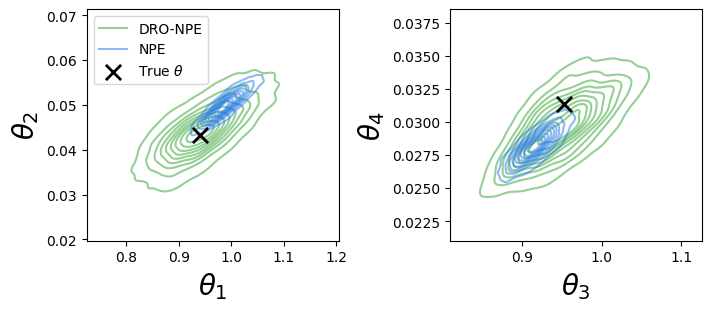

In [11]:
fig = plot_posterior_comparison(index = 1, n_post = 5000)

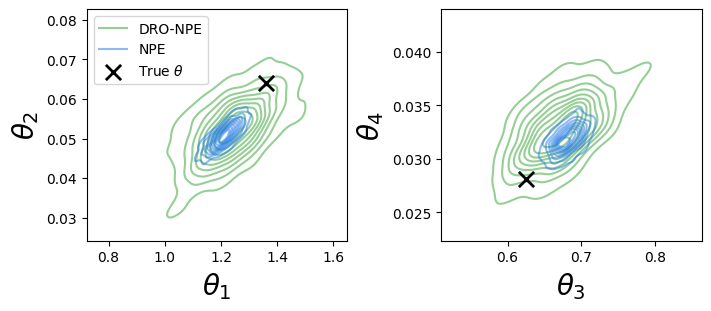

In [12]:
fig = plot_posterior_comparison(index = 2, n_post = 1000)

We observe that NPE yields overconfident posterior, far from the true $\theta$, wheres DRO-NPE yields conservative posterior covering the true $\theta$.

### Coverage curve

It plots the nominal coverage on the x-axis and coverage of HPDR of approximate posterior on the y-axis.

The diagonal denotes perfect coverage, with curves above indicating conservativeness and curves below overconfidence. 

In [13]:
from src.diagnostics.coverage import compute_coverage_scores, compute_coverage 

def coverage_curve(data, post_samples, approximator, label, color):
    score_true, scores_samples = compute_coverage_scores(
        data, post_samples, approximator
    )
    alpha_values = np.linspace(0, 1, 20)
    target_coverage = 1 - alpha_values
    coverage = compute_coverage(data, post_samples, approximator, alpha_values, score_true = score_true, scores_samples = scores_samples)

    fig, ax = plt.subplots(1, 1, figsize=(3, 3), constrained_layout=True)
    ax.plot(target_coverage, coverage, color = color, label = label)
    ax.plot([0, 1], [0, 1], "k--", linewidth=1.5, alpha=0.6, label="Perfect coverage")

    ax.set_xlabel(r"$1 - \alpha$", fontsize = 20)
    ax.set_ylabel(r"Coverage", fontsize = 20)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.legend(frameon=True, fontsize = 10, loc = "upper left")
    return fig

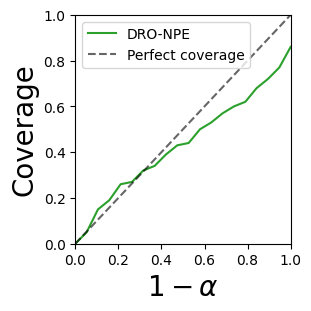

In [14]:
f = coverage_curve(test_data, post_samples_dro, approximator_dro, "DRO-NPE", "#2ca02c")

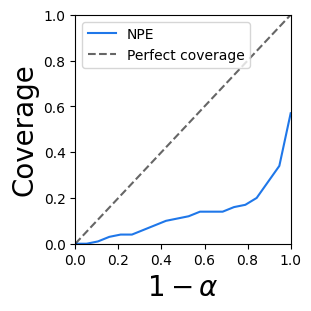

In [15]:
f = coverage_curve(test_data, post_samples_npe, approximator_npe, "NPE", "#1f77e9")


We observe that DRO-NPE yields better coverage than NPE.

### NLPD
Next, we calculate NLPD, which is average of log posterior density evaluated at test data

In [16]:
nlpd_dro = - approximator_dro.log_prob(test_data)
nlpd_npe = - approximator_npe.log_prob(test_data)

print("-----NLPD------")
print(f"DRO-NPE: {nlpd_dro.mean()}")
print(f"NPE: {nlpd_npe.mean()}")


-----NLPD------
DRO-NPE: -8.454081535339355
NPE: -1.4350298643112183


We observe that DRO-NPE yields better NLPD than NPE.

### KL-based calibration
Finally, we calculate $kl_\mathrm{cal}^q$, proposed metric for calibration.

In [17]:
from src.diagnostics.kl_based_calibration import kl_cal_q

kl_cal_dro = kl_cal_q(test_data, post_samples_dro, approximator_dro)
kl_cal_npe = kl_cal_q(test_data, post_samples_npe, approximator_npe)

print("-----KL-cal------")
print(f"DRO-NPE: {kl_cal_dro}")
print(f"NPE: {kl_cal_npe}")

-----KL-cal------
DRO-NPE: 0.006952979208974736
NPE: 0.5825976840941044


We observe that DRO-NPE yields better  $kl_\mathrm{cal}^q$ than NPE.